In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.metrics import f1_score, roc_auc_score
from scipy.stats import skew
from scipy.stats import kurtosis

## Dataset loading - ucitavanje dataseta

In [4]:
df=pd.read_csv('../datasets/dataset1.csv')

## Display info about data and first five columns - prikaz informacija o datasetu i prvih 5 kolona iz dataseta

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dob                       1205 non-null   int64  
 1   sistolicki_krvni_tlak     1200 non-null   float64
 2   dijastolicki_krvni_tlak   1201 non-null   float64
 3   glukoza_u_krvi            1203 non-null   float64
 4   tjelesna_temp             1205 non-null   int64  
 5   BMI                       1187 non-null   float64
 6   komplikacije_u_proslosti  1203 non-null   float64
 7   dijabetes                 1203 non-null   float64
 8   gestacijski_dijabetes     1205 non-null   int64  
 9   mentalno_zdravlje         1205 non-null   int64  
 10  otkucaji_srca             1203 non-null   float64
 11  nivo_rizika               1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


In [6]:
df.head()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## Converting Farenheit into Celsius - pretvaranje Farenhajta u stepene Celzijusove skale

In [7]:
df['tjelesna_temp'] = ((df['tjelesna_temp'] - 32) * 5/9).round(2)

In [8]:
df.head()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
0,22,90.0,60.0,9.0,37.78,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,36.67,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,36.67,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,36.67,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,36.67,19.7,0.0,0.0,0,0,74.0,Low


## Preparing to convert categorical column into numerical: showing the unique values from "nivo_rizika" variable
## Pripreme za pretvaranje kategoričkih varijabli u numeričke: prikaz jedinstvenih vrijednosti za varijablu "nivo_rizika"

In [46]:
df['nivo_rizika'].unique()

array(['High', 'Low', nan], dtype=object)

## Displaying the number of missing values related to each variable
## Prikaz broja nedostajućih vrijednosti za svaku varijablu

In [47]:
print(df.isnull().sum()) 

dob                          0
sistolicki_krvni_tlak        5
dijastolicki_krvni_tlak      4
glukoza_u_krvi               2
tjelesna_temp                0
BMI                         18
komplikacije_u_proslosti     2
dijabetes                    2
gestacijski_dijabetes        0
mentalno_zdravlje            0
otkucaji_srca                2
nivo_rizika                 18
dtype: int64


## Calculating skewness for numerical variables
## Računanje asimetrije (skewness) za numeričke varijable

In [48]:
varijable = [
    'sistolicki_krvni_tlak',
    'dijastolicki_krvni_tlak',
    'glukoza_u_krvi',
    'BMI',
    'komplikacije_u_proslosti',
    'dijabetes',
    'otkucaji_srca'
]


skewness_values = {}
for var in varijable:
    if var in df.columns:
       
        podaci = df[var].dropna()
        
        
        if pd.api.types.is_numeric_dtype(podaci):
            skewness_values[var] = skew(podaci)
        else:
            print(f"Varijabla '{var}' nije numerička. Skewness se ne računa.")
            skewness_values[var] = None
    else:
        print(f"Varijabla '{var}' ne postoji u DataFrame-u.")
        skewness_values[var] = None


print("\nKoeficijent iskrivljenosti (skewness):")
for var, sk in skewness_values.items():
    if sk is not None:
        print(f"{var}: {sk:.4f}")
    else:
        print(f"{var}: nije izračunat")


Koeficijent iskrivljenosti (skewness):
sistolicki_krvni_tlak: 0.2571
dijastolicki_krvni_tlak: 0.3772
glukoza_u_krvi: 1.5781
BMI: 0.4574
komplikacije_u_proslosti: 1.7071
dijabetes: 0.9339
otkucaji_srca: 0.2097


## Filling the missing values of numerical variables with mean and median 
## Popunjavanje nedostajućih vrijednosti za numeričke varijable putem mean i median vrijednosti

In [49]:
skewness_dict = {
    'sistolicki_krvni_tlak': 0.2571,
    'dijastolicki_krvni_tlak': 0.3772,
    'glukoza_u_krvi': 1.5781,
    'BMI': 0.4574,
    'komplikacije_u_proslosti': 1.7071,
    'dijabetes': 0.9339,
    'otkucaji_srca': 0.2097
}

for var, skew_val in skewness_dict.items():
    if var not in df.columns:
        print(f"Varijabla '{var}' ne postoji u DataFrame-u.")
        continue
    
    if skew_val < -1 or skew_val > 1:
        fill_value = df[var].median(skipna=True)
        method = "median"
    else:
        fill_value = df[var].mean(skipna=True)
        method = "mean"
    
    df[var] = df[var].fillna(fill_value)
    
    print(f"{var}: skew={skew_val:.4f} → popunjeno sa {method} = {fill_value:.4f}")

# Provjera
print("\nPreostale missing vrijednosti:")
print(df[list(skewness_dict.keys())].isnull().sum())

sistolicki_krvni_tlak: skew=0.2571 → popunjeno sa mean = 116.8192
dijastolicki_krvni_tlak: skew=0.3772 → popunjeno sa mean = 77.1665
glukoza_u_krvi: skew=1.5781 → popunjeno sa median = 6.9000
BMI: skew=0.4574 → popunjeno sa mean = 23.3151
komplikacije_u_proslosti: skew=1.7071 → popunjeno sa median = 0.0000
dijabetes: skew=0.9339 → popunjeno sa mean = 0.2884
otkucaji_srca: skew=0.2097 → popunjeno sa mean = 75.8171

Preostale missing vrijednosti:
sistolicki_krvni_tlak       0
dijastolicki_krvni_tlak     0
glukoza_u_krvi              0
BMI                         0
komplikacije_u_proslosti    0
dijabetes                   0
otkucaji_srca               0
dtype: int64


## Filling the missing values of categorocial variable with mode
## Popunjavanje nedostajućih vrijednosti za kategoričku varijablu korištenje mode vrijednosti

In [50]:
print(df['nivo_rizika'].value_counts(dropna=False))

nivo_rizika
Low     713
High    474
NaN      18
Name: count, dtype: int64


In [51]:
mod_value = df['nivo_rizika'].mode()[0]
df['nivo_rizika'] = df['nivo_rizika'].fillna(mod_value)
print(f"Popunjeno s modom: {mod_value}")

Popunjeno s modom: Low


## Encoding categorical columns
## Enkodiranje kategoričkih varijabli

In [52]:
encoder = LabelEncoder()

In [53]:
df['nivo_rizika'].unique()

array(['High', 'Low'], dtype=object)

In [54]:
df['nivo_rizika'] = df['nivo_rizika'].map({'High':1, 'Low':0})

In [55]:
df.head()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
0,22,90.0,60.0,9.0,37.78,18.0,1.0,1.0,0,1,80.0,1
1,22,110.0,70.0,7.1,36.67,20.4,0.0,0.0,0,0,74.0,0
2,27,110.0,70.0,7.5,36.67,23.0,1.0,0.0,0,0,72.0,0
3,20,100.0,70.0,7.2,36.67,21.2,0.0,0.0,0,0,74.0,0
4,20,90.0,60.0,7.5,36.67,19.7,0.0,0.0,0,0,74.0,0


## Descriptive statistic
## Deskriptivna statistika

In [56]:
df.describe()

,dob,sistolicki_krvni_tlak,dijastolicki_krvni_tlak,glukoza_u_krvi,tjelesna_temp,BMI,komplikacije_u_proslosti,dijabetes,gestacijski_dijabetes,mentalno_zdravlje,otkucaji_srca,nivo_rizika
count,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.00000,1205.000000,1205.000000
mean,27.731950,116.819167,77.166528,7.500066,36.889320,23.315080,0.175104,0.288446,0.117842,0.33444,75.817124,0.393361
std,12.571074,18.676601,14.281365,3.047087,0.603329,3.846602,0.380214,0.452851,0.322555,0.47199,7.221333,0.488699
min,10.000000,70.000000,40.000000,3.000000,36.110000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000,0.000000
25%,21.000000,100.000000,65.000000,6.000000,36.670000,21.000000,0.000000,0.000000,0.000000,0.00000,70.000000,0.000000
50%,25.000000,120.000000,80.000000,6.900000,36.670000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000,0.000000
75%,32.000000,130.000000,90.000000,7.900000,36.670000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000,1.000000
max,325.000000,200.000000,140.000000,19.000000,39.440000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000,1.000000


## Calculating the kurtosis value for numerical variables
## Računanje zaobljenosti (kurtosis) za numeričke varijable

In [57]:
varijable = [
    'sistolicki_krvni_tlak',
    'dijastolicki_krvni_tlak',
    'glukoza_u_krvi',
    'BMI',
    'komplikacije_u_proslosti',
    'dijabetes',
    'otkucaji_srca'
]

# Izračun kurtosis za svaku varijablu (ignorirajući NaN)
kurtosis_values = {}
for var in varijable:
    if var in df.columns:
        # Ukloni missing vrijednosti
        podaci = df[var].dropna()
        
        # Provjera jesu li podaci numerički
        if pd.api.types.is_numeric_dtype(podaci):
            # Fisher's kurtosis (excess) – normalna distribucija ima 0
            kurtosis_values[var] = kurtosis(podaci, fisher=True)
        else:
            print(f"Varijabla '{var}' nije numerička. Kurtosis se ne računa.")
            kurtosis_values[var] = None
    else:
        print(f"Varijabla '{var}' ne postoji u DataFrame-u.")
        kurtosis_values[var] = None

print("\nKoeficijent kurtosisa (Fisher, excess kurtosis):")
print("(0 = normalna distribucija, >0 = oštriji vrh, <0 = plosnatiji vrh)")
for var, kurt in kurtosis_values.items():
    if kurt is not None:
        print(f"{var}: {kurt:.4f}")
    else:
        print(f"{var}: nije izračunat")


Koeficijent kurtosisa (Fisher, excess kurtosis):
(0 = normalna distribucija, >0 = oštriji vrh, <0 = plosnatiji vrh)
sistolicki_krvni_tlak: 0.3652
dijastolicki_krvni_tlak: -0.2866
glukoza_u_krvi: 2.6322
BMI: 1.2825
komplikacije_u_proslosti: 0.9232
dijabetes: -1.1247
otkucaji_srca: -0.1681


## Histograms for numeric variables
## Prikaz histograma za numeričke varijable

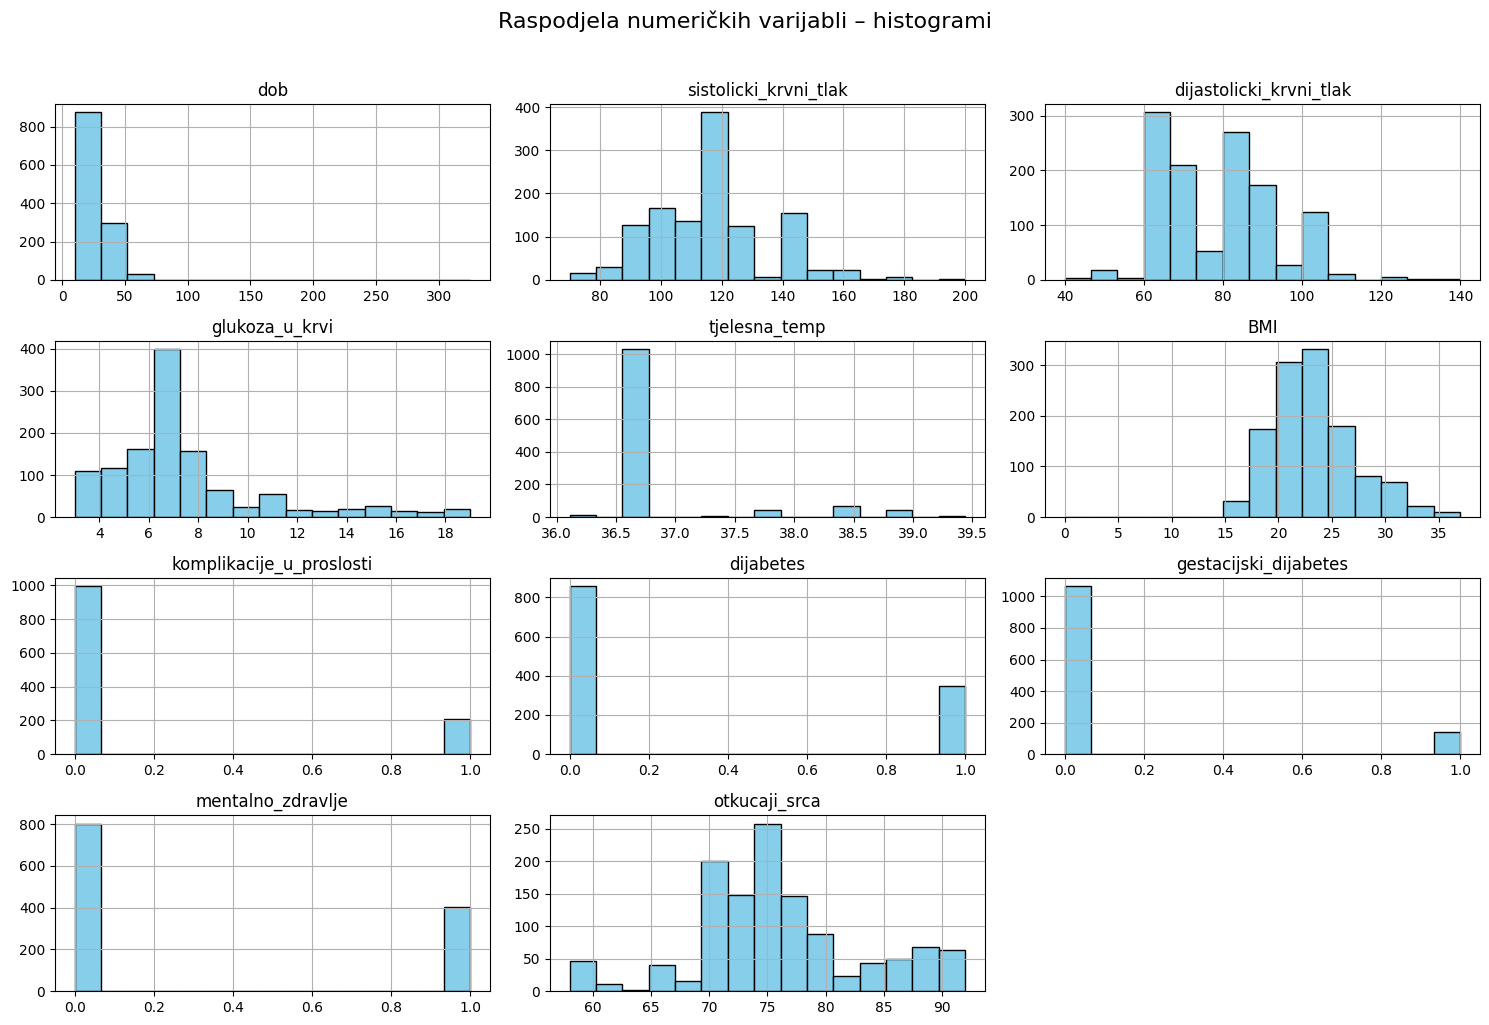

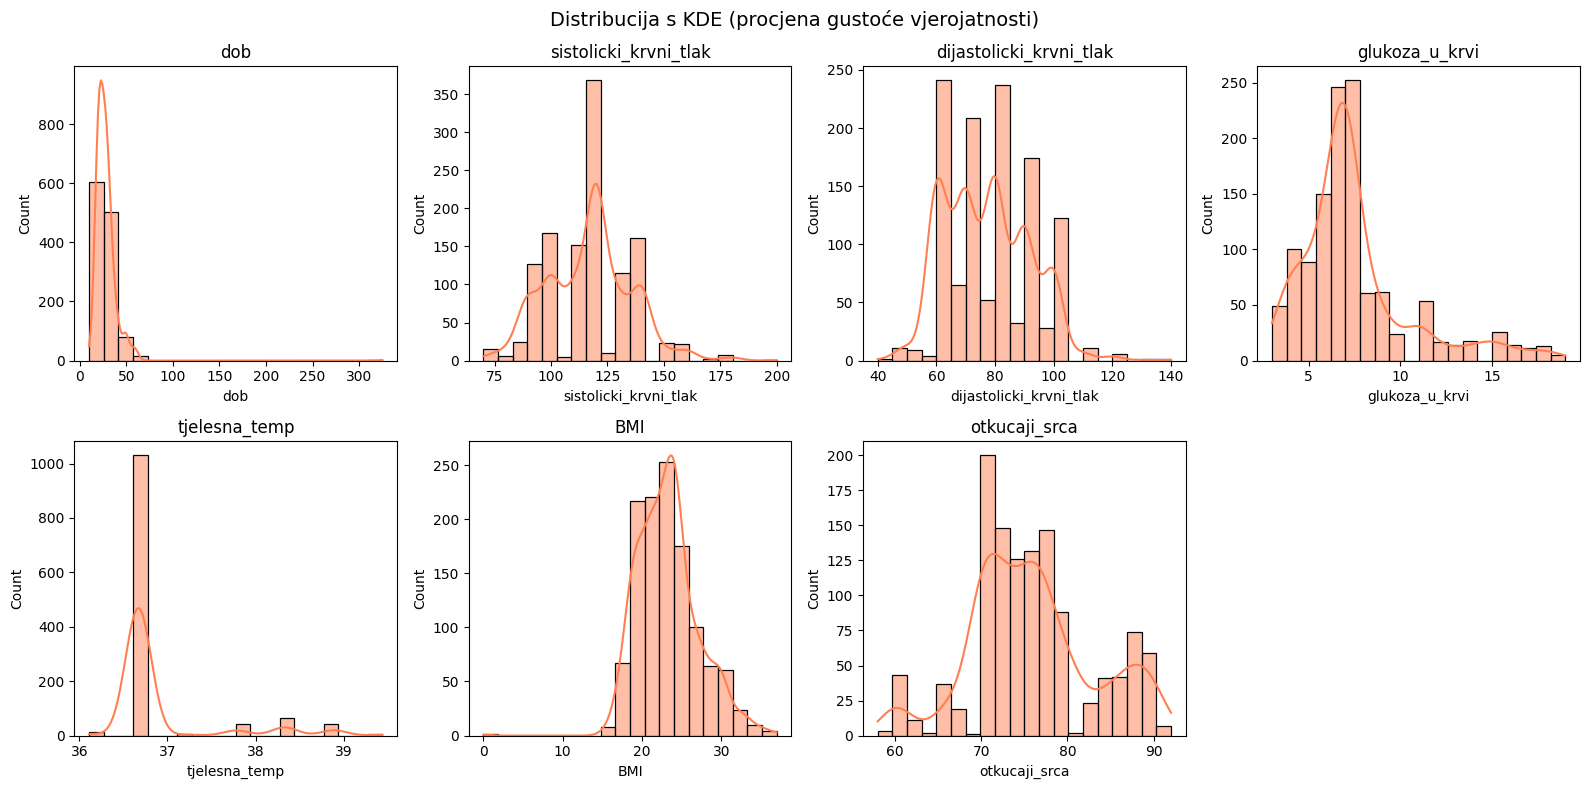

In [58]:
numericke_za_graf = [
    'dob',
    'sistolicki_krvni_tlak',
    'dijastolicki_krvni_tlak',
    'glukoza_u_krvi',
    'tjelesna_temp',
    'BMI',
    'komplikacije_u_proslosti',
    'dijabetes',
    'gestacijski_dijabetes',
    'mentalno_zdravlje',
    'otkucaji_srca'
]

# Uklonite varijable koje ne postoje u DataFrame-u (da ne baci grešku)
postojece = [var for var in numericke_za_graf if var in df.columns]
if len(postojece) != len(numericke_za_graf):
    print("Upozorenje: sljedeće varijable ne postoje u DataFrame-u:")
    print(set(numericke_za_graf) - set(postojece))

# --- 1. HISTOGRAMI (kao u primjeru) ---
df[postojece].hist(bins=15, figsize=(15, 10), layout=(4, 3), 
                   color='skyblue', edgecolor='black')
plt.suptitle('Raspodjela numeričkih varijabli – histogrami', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- Density plot (KDE) za glavne kontinuirane varijable ---
kontinuirane = ['dob', 'sistolicki_krvni_tlak', 'dijastolicki_krvni_tlak', 
                'glukoza_u_krvi', 'tjelesna_temp', 'BMI', 
                'otkucaji_srca']
kontinuirane = [var for var in kontinuirane if var in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, var in enumerate(kontinuirane):
    sns.histplot(df[var], kde=True, bins=20, ax=axes[i], color='coral')
    axes[i].set_title(var)
# sakrij neiskorištene subplotove
for j in range(len(kontinuirane), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribucija s KDE (procjena gustoće vjerojatnosti)', fontsize=14)
plt.tight_layout()
plt.show()

## Pie chart for categorical variable - "level of risk"
## Prikaz "pie chart-a" za kategoričku varijablu -> nivo_rizika

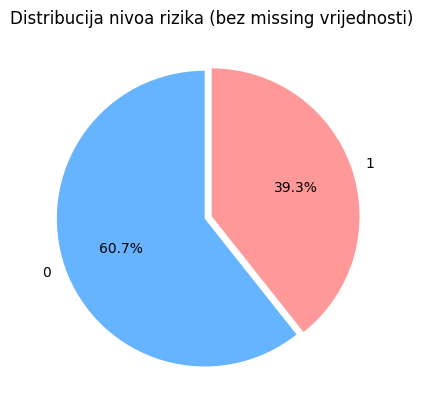

In [59]:
podaci = df['nivo_rizika'].dropna()
podaci.value_counts().plot(kind='pie', autopct='%1.1f%%', 
                           colors=['#66b3ff','#ff9999',], 
                           startangle=90, explode=(0.05, 0))
plt.title('Distribucija nivoa rizika (bez missing vrijednosti)')
plt.ylabel('')  
plt.show()

## Correlation matrix
## Korelacijska matrica

In [60]:
correlation_matrix = df.corr(method='pearson')
print(correlation_matrix)

                               dob  sistolicki_krvni_tlak  \
dob                       1.000000               0.159969   
sistolicki_krvni_tlak     0.159969               1.000000   
dijastolicki_krvni_tlak   0.155933               0.793037   
glukoza_u_krvi            0.430698               0.342517   
tjelesna_temp            -0.089032              -0.178958   
BMI                       0.235153               0.285468   
komplikacije_u_proslosti  0.142762               0.133473   
dijabetes                 0.177791               0.165030   
gestacijski_dijabetes    -0.049966               0.137663   
mentalno_zdravlje         0.076573               0.184942   
otkucaji_srca             0.062851               0.156271   
nivo_rizika               0.128037               0.288258   

                          dijastolicki_krvni_tlak  glukoza_u_krvi  \
dob                                      0.155933        0.430698   
sistolicki_krvni_tlak                    0.793037        0.342517   

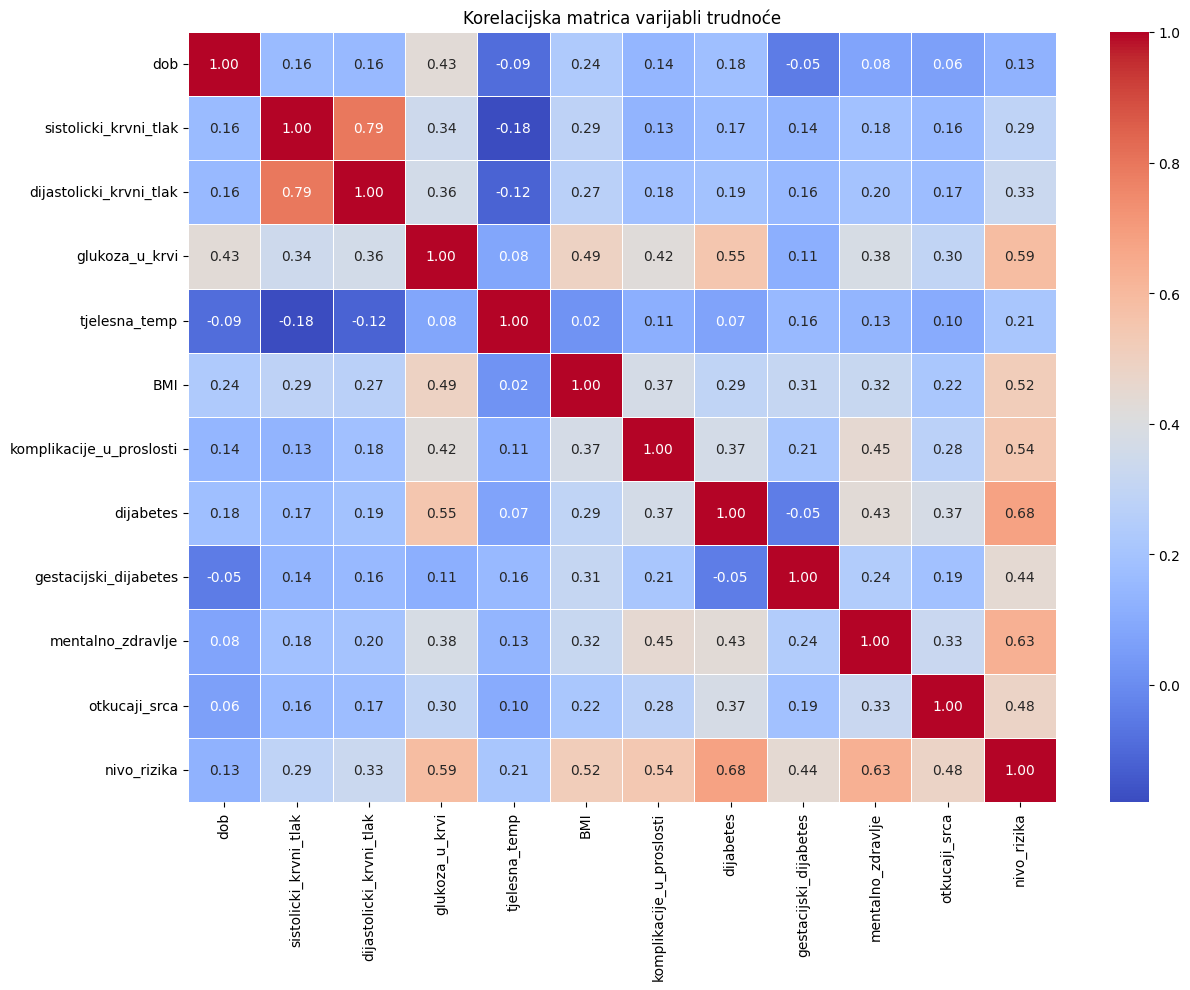

In [61]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Korelacijska matrica varijabli trudnoće')
plt.show()

## Train and test split
## Dijeljenje dataseta na trening i test set

In [62]:
x = df.drop(columns=['nivo_rizika'])
y = df['nivo_rizika']

In [63]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dob                       1205 non-null   int64  
 1   sistolicki_krvni_tlak     1205 non-null   float64
 2   dijastolicki_krvni_tlak   1205 non-null   float64
 3   glukoza_u_krvi            1205 non-null   float64
 4   tjelesna_temp             1205 non-null   float64
 5   BMI                       1205 non-null   float64
 6   komplikacije_u_proslosti  1205 non-null   float64
 7   dijabetes                 1205 non-null   float64
 8   gestacijski_dijabetes     1205 non-null   int64  
 9   mentalno_zdravlje         1205 non-null   int64  
 10  otkucaji_srca             1205 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 103.7 KB


In [64]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1205 entries, 0 to 1204
Series name: nivo_rizika
Non-Null Count  Dtype
--------------  -----
1205 non-null   int64
dtypes: int64(1)
memory usage: 9.5 KB


In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0, stratify=y)

### This line splits the data into training and testing sets, with 20% of the data allocated for testing. The stratify=y parameter ensures that the class distribution in the target variable is preserved in both subsets, which is important for imbalanced classification problems.
### Ova linija koda dijeli podatke na trening i test skupove, pri čemu se 20% podataka izdvaja za testiranje. Parametar stratify=y osigurava da omjer klasa u ciljnoj varijabli ostane isti u oba skupa, što je važno kod neuravnoteženih klasa.

In [68]:
y_test.value_counts()

nivo_rizika
0    148
1     93
Name: count, dtype: int64

### In the y_test set, we have 148 pregnant women with label 0 (low risk, normal condition) and 93 pregnant women with label 1 (increased risk). This indicates that the dataset is not too "skewed" to one side because there are enough examples for both healthy and high-risk cases.
### U y_test skupu imamo 148 trudnica sa oznakom 0 (nizak rizik normalno stanje), a 93 trudnice sa oznakom 1 (povećan rizik). Ovo govori da dataset nije previše "nagnut" na jednu stranu jer postoji dovoljno primjera i za zdrave i za rizične slučajeve.

## Data scaling

In [67]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Za k-NN i SVM koristimo skalirane podatke jer oni ovise o udaljenostima. Ostali algoritmi nisu osjetljivi na skaliranje

In [69]:
x_train

array([[ 3.48840033, -1.4702896 , -0.87850711, ..., -0.358895  ,
        -0.72312294,  0.15845416],
       [-0.91811744,  0.1360697 ,  0.17627043, ..., -0.358895  ,
        -0.72312294, -0.7976272 ],
       [ 0.47907112,  0.1360697 ,  0.87945545, ..., -0.358895  ,
        -0.72312294, -0.7976272 ],
       ...,
       [-1.67044975, -1.4702896 , -1.23009962, ..., -0.358895  ,
        -0.72312294, -1.34395941],
       [ 3.48840033,  1.20697591,  0.17627043, ..., -0.358895  ,
         1.38289071, -2.16345772],
       [-1.67044975,  0.1360697 ,  1.23104796, ..., -0.358895  ,
        -0.72312294, -2.16345772]], shape=(964, 11))

### Function for evaluating classification model
### Funkcija za evaluaciju klasifikacijskog modela

In [74]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    return metrics, y_pred, y_proba

### Function for evaluating regression model
### Funkcija za evaluaciju regresijskog modela

In [75]:
def evaluate_regressor(model, X_train, y_train_reg, X_test, y_test_reg):
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    return {
        "MSE": mean_squared_error(y_test_reg, y_pred),
        "MAE": mean_absolute_error(y_test_reg, y_pred),
        "R2": r2_score(y_test_reg, y_pred)
    }

In [76]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = {}
for name, clf in classifiers.items():
    print(f"\nEvaluacija: {name}")
    metrics, _, _ = evaluate_classifier(clf, x_train, y_train, x_test, y_test)
    results[name] = metrics
    for metric, value in metrics.items():
        if value is not None:
            print(f"  {metric}: {value:.4f}")
        else:
            print(f"  {metric}: nije podržan (nema predict_proba)")


Evaluacija: Logistic Regression
  Accuracy: 0.9751
  Precision: 0.9785
  Recall: 0.9579
  F1 Score: 0.9681
  ROC AUC: 0.9937

Evaluacija: Decision Tree
  Accuracy: 0.9668
  Precision: 0.9485
  Recall: 0.9684
  F1 Score: 0.9583
  ROC AUC: 0.9671

Evaluacija: Random Forest
  Accuracy: 0.9793
  Precision: 0.9688
  Recall: 0.9789
  F1 Score: 0.9738
  ROC AUC: 0.9937

Evaluacija: SVM (RBF)
  Accuracy: 0.8755
  Precision: 0.9333
  Recall: 0.7368
  F1 Score: 0.8235
  ROC AUC: 0.9121

Evaluacija: k-NN (k=5)
  Accuracy: 0.9004
  Precision: 0.9494
  Recall: 0.7895
  F1 Score: 0.8621
  ROC AUC: 0.9503

Evaluacija: Gradient Boosting
  Accuracy: 0.9876
  Precision: 0.9792
  Recall: 0.9895
  F1 Score: 0.9843
  ROC AUC: 0.9941

Evaluacija: Naive Bayes
  Accuracy: 0.9585
  Precision: 0.9381
  Recall: 0.9579
  F1 Score: 0.9479
  ROC AUC: 0.9866


In [78]:
def cross_validate_classifier(model, x, y, cv=5):
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    scores = cross_validate(model, x, y, cv=cv, scoring=scoring)
    results = {f"test_{metric}": scores[f"test_{metric}"].mean() for metric in scoring}
    return results

print("\n--- CROSS-VALIDATION (5-fold) ---")
for name, clf in classifiers.items():
    print(f"\n{name}:")
    cv_res = cross_validate_classifier(clf, x, y, cv=5)
    for k, v in cv_res.items():
        print(f"  {k}: {v:.4f}")


--- CROSS-VALIDATION (5-fold) ---

Logistic Regression:
  test_accuracy: 0.9336
  test_precision: 0.9422
  test_recall: 0.8834
  test_f1: 0.9077
  test_roc_auc: 0.9851

Decision Tree:
  test_accuracy: 0.9311
  test_precision: 0.9094
  test_recall: 0.9259
  test_f1: 0.9139
  test_roc_auc: 0.9301

Random Forest:
  test_accuracy: 0.9519
  test_precision: 0.9425
  test_recall: 0.9364
  test_f1: 0.9378
  test_roc_auc: 0.9917

SVM (RBF):
  test_accuracy: 0.8539
  test_precision: 0.9392
  test_recall: 0.6724
  test_f1: 0.7679
  test_roc_auc: 0.8990

k-NN (k=5):
  test_accuracy: 0.8822
  test_precision: 0.9265
  test_recall: 0.7610
  test_f1: 0.8248
  test_roc_auc: 0.9269

Gradient Boosting:
  test_accuracy: 0.9552
  test_precision: 0.9565
  test_recall: 0.9280
  test_f1: 0.9405
  test_roc_auc: 0.9927

Naive Bayes:
  test_accuracy: 0.9419
  test_precision: 0.8961
  test_recall: 0.9662
  test_f1: 0.9292
  test_roc_auc: 0.9836


In [79]:
compare_df = pd.DataFrame(results).T
print("\n--- Usporedba algoritama (test set) ---")
print(compare_df)

# Sortiranje po F1 score
best_f1 = compare_df['F1 Score'].idxmax()
print(f"\nNajbolji algoritam po F1 score: {best_f1}")


--- Usporedba algoritama (test set) ---
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.975104   0.978495  0.957895  0.968085  0.993727
Decision Tree        0.966805   0.948454  0.968421  0.958333  0.967087
Random Forest        0.979253   0.968750  0.978947  0.973822  0.993727
SVM (RBF)            0.875519   0.933333  0.736842  0.823529  0.912112
k-NN (k=5)           0.900415   0.949367  0.789474  0.862069  0.950288
Gradient Boosting    0.987552   0.979167  0.989474  0.984293  0.994088
Naive Bayes          0.958506   0.938144  0.957895  0.947917  0.986590

Najbolji algoritam po F1 score: Gradient Boosting


### Confussion matrix
### Matrica konfuzije

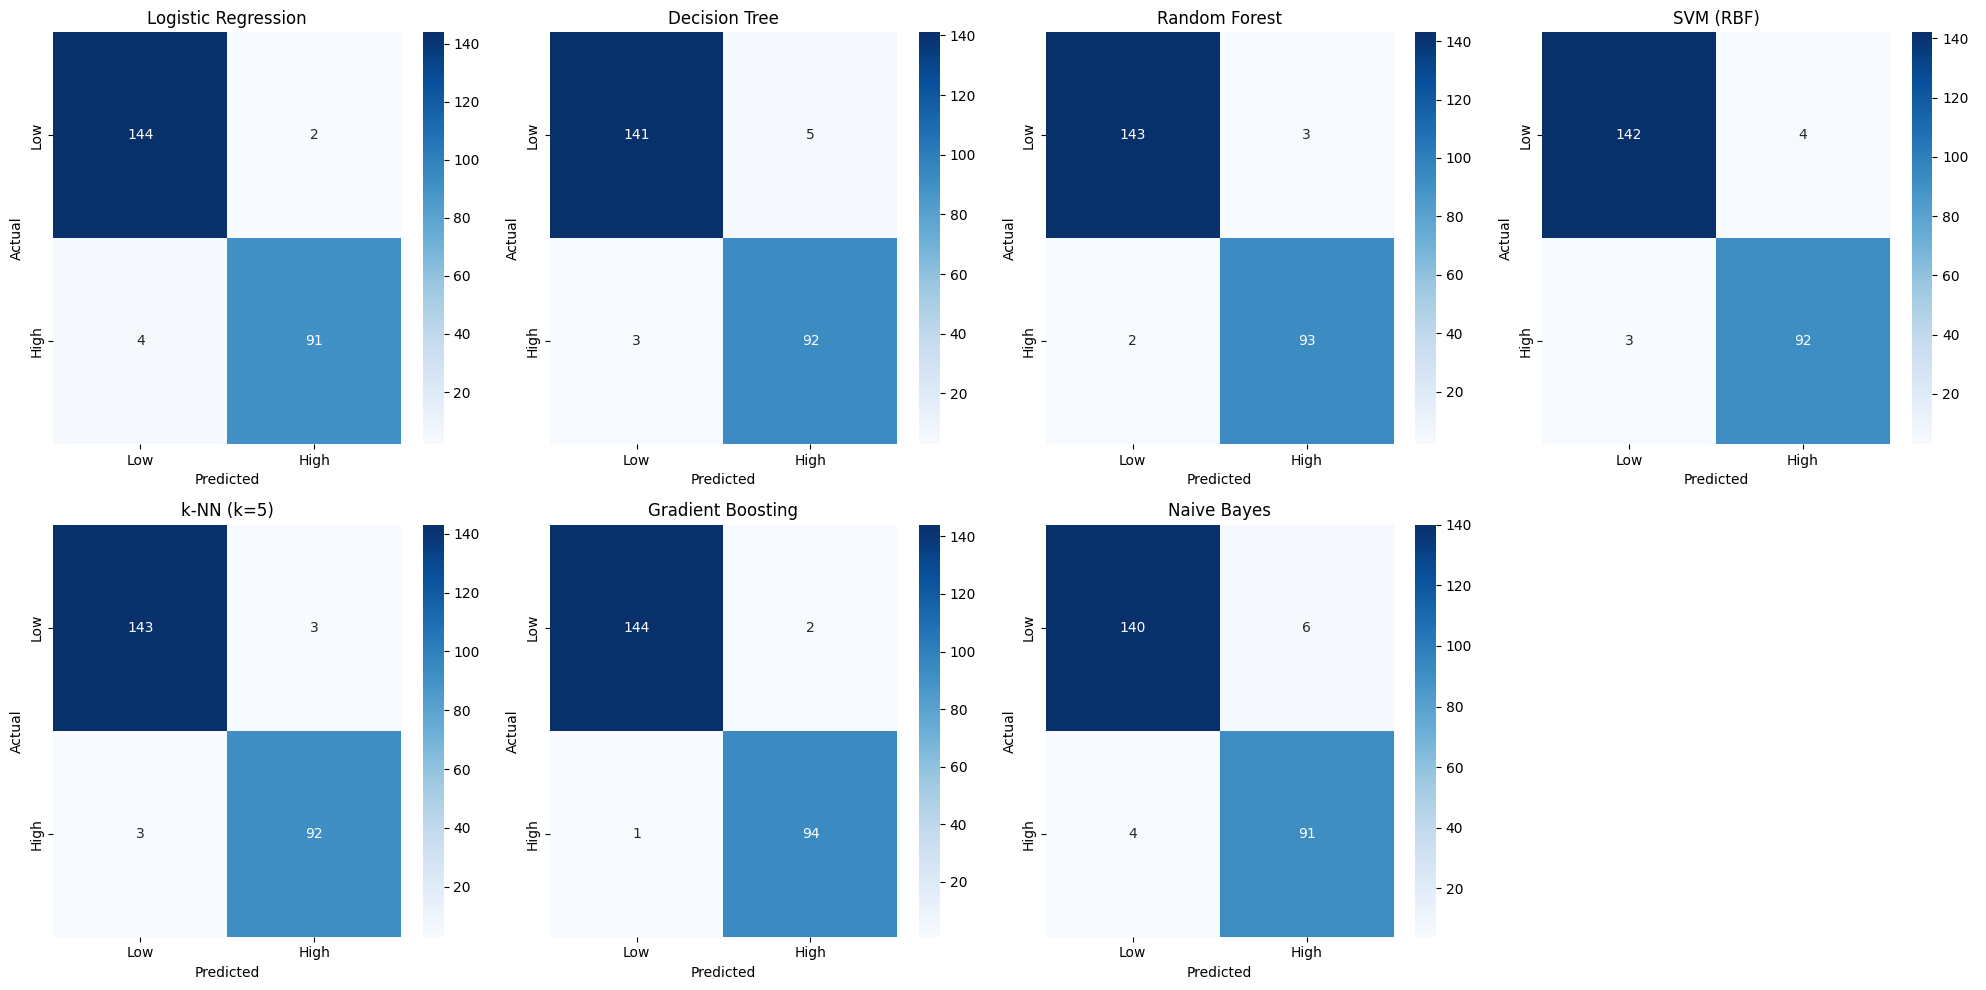


--- Numeričke vrijednosti konfuzijskih matrica ---

Logistic Regression:
  True Negatives (Low correctly predicted): 144
  False Positives (Low predicted as High): 2
  False Negatives (High predicted as Low): 4
  True Positives (High correctly predicted): 91

Decision Tree:
  True Negatives (Low correctly predicted): 141
  False Positives (Low predicted as High): 5
  False Negatives (High predicted as Low): 3
  True Positives (High correctly predicted): 92

Random Forest:
  True Negatives (Low correctly predicted): 143
  False Positives (Low predicted as High): 3
  False Negatives (High predicted as Low): 2
  True Positives (High correctly predicted): 93

SVM (RBF):
  True Negatives (Low correctly predicted): 142
  False Positives (Low predicted as High): 4
  False Negatives (High predicted as Low): 3
  True Positives (High correctly predicted): 92

k-NN (k=5):
  True Negatives (Low correctly predicted): 143
  False Positives (Low predicted as High): 3
  False Negatives (High predicte

In [83]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

# Podjela podataka (već morate imati X_train, y_train, X_test, y_test)
# Ako niste još podijelili, ispod je primjer:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Za SVM i k-NN preporučamo skaliranje (inače mogu loše raditi)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Prilagodba: za svaki model koristimo odgovarajuće podatke (skalirane za SVM i k-NN)
# Za ostale algoritme koristimo originalne (neskalirane) podatke – ali možete koristiti skalirane za sve, nije greška.

# Rječnik koji definira koje podatke koristiti za koji model
data_for_model = {
    "Logistic Regression": (x_train, x_test),
    "Decision Tree": (x_train, x_test),
    "Random Forest": (x_train, x_test),
    "SVM (RBF)": (X_train_scaled, X_test_scaled),
    "k-NN (k=5)": (X_train_scaled, X_test_scaled),
    "Gradient Boosting": (x_train, x_test),
    "Naive Bayes": (x_train, x_test)
}

# Crtanje svih confusion matrica u jednom figure-u (subplot)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  # 2 reda, 4 kolone
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    X_tr, X_te = data_for_model[name]
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Sakrij neiskorišteni subplot (ako ih ima više od modela)
for j in range(len(models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Alternativno: ispis numeričkih vrijednosti za svaku matricu (TP, TN, FP, FN)
print("\n--- Numeričke vrijednosti konfuzijskih matrica ---")
for name, model in models.items():
    X_tr, X_te = data_for_model[name]
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"\n{name}:")
    print(f"  True Negatives (Low correctly predicted): {tn}")
    print(f"  False Positives (Low predicted as High): {fp}")
    print(f"  False Negatives (High predicted as Low): {fn}")
    print(f"  True Positives (High correctly predicted): {tp}")

## 5‑fold cross‑validation is crucial for assessing model stability and generalization, especially in medical applications.
### If a model performs excellently on the training set but poorly on cross‑validation, that is a sign of overfitting.
### Small standard deviations (±0.008) mean that the model is stable – it behaves consistently across different data subsets, which is crucial for medical applications.
### 5-fold križna validacija je ključna za procjenu stabilnosti i generalizacije modela, posebno u medicinskim primjenama.
### Ako model ima odlične rezultate na trening skupu, ali loše na križnoj validaciji, to je znak overfittinga.
### Male standardne devijacije (±0.008) znače da je model stabilan – ponaša se dosljedno na različitim podskupovima podataka, što je ključno za medicinsku primjenu.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

models_with_scaling = {
    "SVM (RBF)": Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=42))]),
    "k-NN (k=5)": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
}

# Spajanje svih modela
all_models = {**models, **models_with_scaling}

# Metrike koje želimo evaluirati
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Stratificirani KFold (čuva omjer klasa)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in all_models.items():
    scores = cross_validate(model, x, y, cv=cv, scoring=scoring, 
                            return_train_score=False, n_jobs=-1)
    mean_scores = {f'mean_{m}': np.mean(scores[f'test_{m}']) for m in scoring}
    std_scores = {f'std_{m}': np.std(scores[f'test_{m}']) for m in scoring}
    results.append({
        'Model': name,
        **mean_scores,
        **std_scores
    })

# Prikaz rezultata
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Poredaj po srednjem F1 score (najbolji prvi)
results_df = results_df.sort_values('mean_f1', ascending=False)

print("=== REZULTATI 5-FOLD KRIŽNE VALIDACIJE ===\n")
print(results_df[['Model', 'mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'mean_roc_auc']])

# ispis najboljeg modela po F1 + standardne devijacije
best_model = results_df.iloc[0]
print(f"\n📌 Najbolji model po F1 score: {best_model['Model']}")
print(f"   F1 = {best_model['mean_f1']:.4f} ± {best_model['std_f1']:.4f}")
print(f"   Recall = {best_model['mean_recall']:.4f} ± {best_model['std_recall']:.4f}")
print(f"   AUC = {best_model['mean_roc_auc']:.4f} ± {best_model['std_roc_auc']:.4f}")

=== REZULTATI 5-FOLD KRIŽNE VALIDACIJE ===

                 Model  mean_accuracy  mean_precision  mean_recall  mean_f1  \
2        Random Forest         0.9867          0.9754       0.9916   0.9833   
3    Gradient Boosting         0.9826          0.9771       0.9789   0.9779   
1        Decision Tree         0.9734          0.9669       0.9663   0.9664   
5            SVM (RBF)         0.9701          0.9530       0.9726   0.9625   
6           k-NN (k=5)         0.9685          0.9527       0.9684   0.9603   
4          Naive Bayes         0.9627          0.9353       0.9725   0.9535   
0  Logistic Regression         0.9635          0.9577       0.9493   0.9534   

   mean_roc_auc  
2        0.9971  
3        0.9970  
1        0.9722  
5        0.9957  
6        0.9886  
4        0.9862  
0        0.9929  

📌 Najbolji model po F1 score: Random Forest
   F1 = 0.9833 ± 0.0082
   Recall = 0.9916 ± 0.0079
   AUC = 0.9971 ± 0.0024


## Conclusion - zakljucak



### The standard deviations are very low for Random Forest (e.g., ±0.0082 for F1) → the model is stable (it behaves consistently across different data subsets).
### Random Forest has the highest recall (0.9916) and the smallest standard deviation (±0.0079) → it reliably "captures" almost all high‑risk patients.
### Standardne devijacije su vrlo niske za Random Forest (npr. ±0.0082 za F1) → model je stabilan (ponaša se dosljedno na različitim podskupovima podataka).
### Random Forest ima najveći recall (0.9916) i najmanju standardnu devijaciju (±0.0079) → pouzdano "hvata" gotovo sve visokorizične pacijente.